In [1]:
import yfinance as yf
import pandas as pd
from datetime import datetime

def scrape_yahoo_finance_history(ticker_symbol, start_date, end_date, output_file):
    """
    Extracts historical market data and saves it to a CSV file.
    """
    print(f"Starting extraction for {ticker_symbol}...")

    try:
        # 1. Initialize the ticker object
        ticker = yf.Ticker(ticker_symbol)

        # 2. Fetch historical data
        # Note: yfinance handles the crumb/cookie requirements automatically
        df = ticker.history(start=start_date, end=end_date)

        if df.empty:
            print("No data found for the specified range.")
            return

        # 3. Data Cleaning/Formatting
        # Reset index to make 'Date' a column instead of the index
        df.reset_index(inplace=True)
        
        # Ensure the date format is clean
        df['Date'] = df['Date'].dt.strftime('%Y-%m-%d')

        # 4. Export to CSV
        df.to_csv(output_file, index=False)
        print(f"Successfully saved data to {output_file}")
        
        return df

    except Exception as e:
        print(f"An error occurred: {e}")

if __name__ == "__main__":
    # Parameters derived from your URL
    # period1=1617773829 (April 7, 2021)
    # period2=1775540222 (Future date, will fetch up to today)
    
    TARGET_TICKER = "CL=F"
    START = "2017-04-07"
    END = "2026-04-08" # Adjust to your desired end date
    OUTPUT = "crude_oil_history.csv"

    scrape_yahoo_finance_history(TARGET_TICKER, START, END, OUTPUT)

Starting extraction for CL=F...
Successfully saved data to crude_oil_history.csv


In [4]:
import pandas as pd

# Load CSV file into a DataFrame
data = pd.read_csv("crude_oil_history.csv")

# Display the first 5 rows
data.head()


,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2017-04-07,51.700001,52.939999,51.490002,52.240002,796437,0.0,0.0
1,2017-04-10,52.310001,53.180000,52.290001,53.080002,565439,0.0,0.0
2,2017-04-11,53.130001,53.450001,52.700001,53.400002,598003,0.0,0.0
3,2017-04-12,53.400002,53.759998,52.709999,53.110001,629805,0.0,0.0
4,2017-04-13,52.849998,53.389999,52.820000,53.180000,480835,0.0,0.0


In [5]:
data['Date'] = pd.to_datetime(data['Date'])

In [6]:
data.shape

(2263, 8)

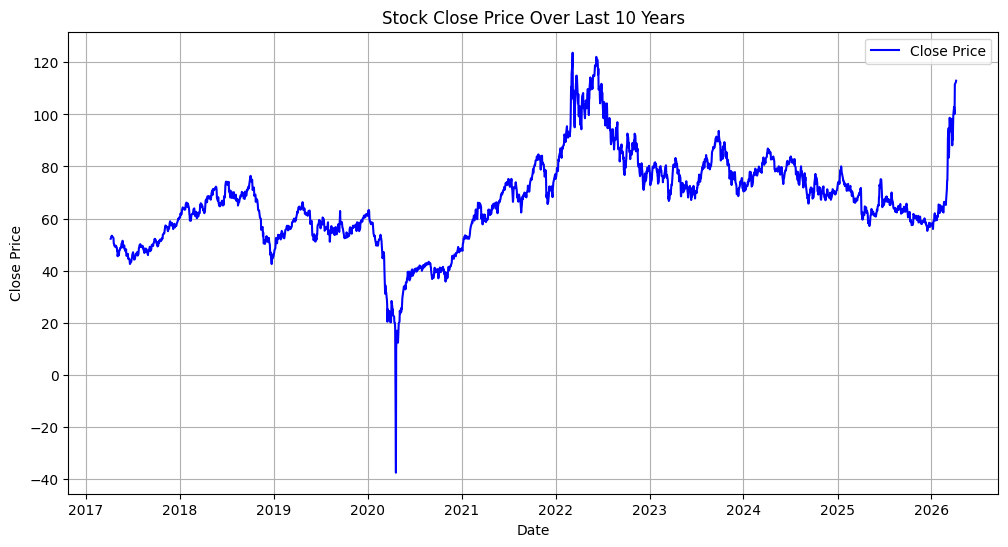

In [7]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(data['Date'][:], data['Close'][:], label='Close Price', color='blue')
# Add labels and title
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.title("Stock Close Price Over Last 10 Years")
plt.legend()
plt.grid(True)
plt.show()

In [8]:
import pandas as pd
import numpy as np

def engineer_oil_features(input_csv, output_csv):
    """
    Transforms raw OHLCV price data into predictive ML features.
    """
    print(f"Loading {input_csv}...")
    
    # 1. Load and Sort Data
    df = pd.read_csv(input_csv)
    df.drop(762,inplace=True)
    df.reset_index(drop=True)
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)

    # 2. Base Price Features (Momentum and Volatility)
    # How much did the price change from yesterday?
    df['Daily_Return_%'] = df['Close'].pct_change() * 100
    
    # How wild was the price swing during the day?
    df['Intraday_Volatility'] = df['High'] - df['Low']
    df['Intraday_Volatility_%'] = (df['Intraday_Volatility'] / df['Open']) * 100

    # 3. Moving Averages (Trend Indicators)
    # 20-day is short-term trend, 50-day is medium, 200-day is macro trend
    df['MA_20'] = df['Close'].rolling(window=20).mean()
    df['MA_50'] = df['Close'].rolling(window=50).mean()
    df['MA_200'] = df['Close'].rolling(window=200).mean()

    # 4. The "Rubber Band" Effect (Anomaly & Bubble Indicators)
    # Calculates how far stretched the current price is from its historical averages
    df['Dist_From_MA20_%'] = ((df['Close'] - df['MA_20']) / df['MA_20']) * 100
    df['Dist_From_MA200_%'] = ((df['Close'] - df['MA_200']) / df['MA_200']) * 100

    # 5. Volume Features (Institutional Activity)
    # A massive volume spike implies institutional buying/dumping
    df['Volume_MA_20'] = df['Volume'].rolling(window=20).mean()
    df['Volume_Spike_Ratio'] = np.where(df['Volume_MA_20'] == 0, 0, df['Volume'] / df['Volume_MA_20'])

    # 6. Define the TARGET Variable (What the ML model will predict)
    # We want to predict if TOMORROW will have a massive swing (>= 4% up or down)
    # We shift the daily return back by 1 day to align tomorrow's result with today's data
    df['Next_Day_Return_%'] = df['Daily_Return_%'].shift(-1)
    
    # Target: 1 if anomaly tomorrow, 0 if normal tomorrow
    df['Target_Anomaly_Tomorrow'] = np.where(df['Next_Day_Return_%'].abs() >= 4.0, 1, 0)

    # 7. Clean Up
    # Drop Yahoo's empty dividend columns and rows with NaN values created by the 200-day window
    df = df.drop(columns=['Dividends', 'Stock Splits'])
    df_clean = df.dropna().reset_index(drop=True)

    # 8. Export Data
    df_clean.to_csv(output_csv, index=False)
    print(f"Success! Generated {len(df_clean)} ML-ready rows. Saved to {output_csv}.")
    
    return df_clean

if __name__ == "__main__":
    engineer_oil_features("crude_oil_history.csv", "engineered_crude_oil.csv")

Loading crude_oil_history.csv...
Success! Generated 2062 ML-ready rows. Saved to engineered_crude_oil.csv.


In [9]:
data1 = pd.read_csv("engineered_crude_oil.csv")

data1=data1[:]

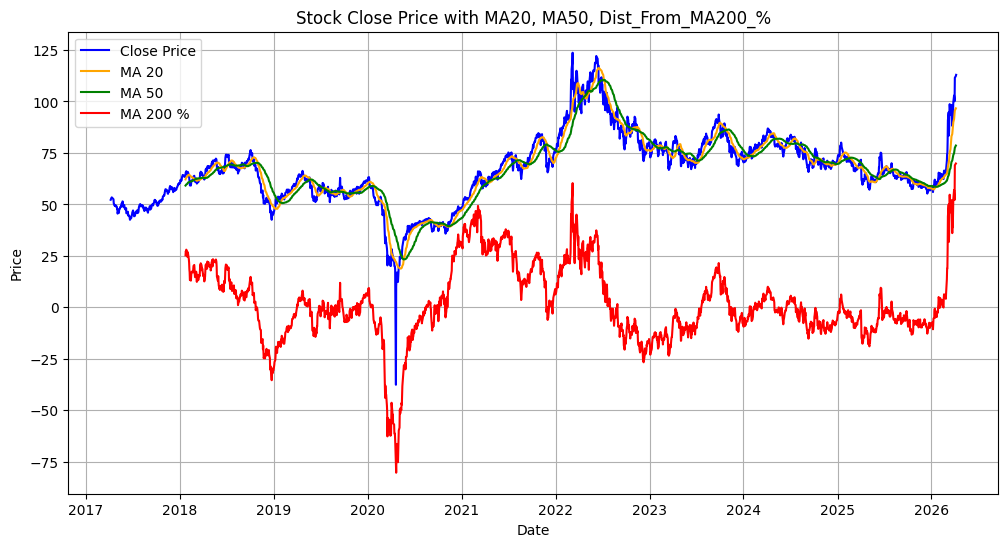

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# Ensure Date column is datetime
data1['Date'] = pd.to_datetime(data1['Date'])

# Plot Close price and moving averages
plt.figure(figsize=(12,6))
plt.plot(data['Date'], data['Close'], label='Close Price', color='blue')
plt.plot(data1['Date'], data1['MA_20'], label='MA 20', color='orange')
plt.plot(data1['Date'], data1['MA_50'], label='MA 50', color='green')
plt.plot(data1['Date'], data1['Dist_From_MA200_%'], label='MA 200 %', color='red')

# Formatting
plt.xlabel("Date")
plt.ylabel("Price")
plt.title("Stock Close Price with MA20, MA50, Dist_From_MA200_%")
plt.legend()
plt.grid(True)

plt.show()

